In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [67]:
rooms = pd.read_csv("D:/dataset/dataset.csv")
rooms.shape

(30000, 9)

In [68]:
rooms.head(30000)

,house_number,distance_from_KU_km,internet_speed_mbps,windows,attached_bathroom,room_size,water_availability,sunlight,price
0,62871,9.3,25,2,shared,12x10,available,moderate,3352
1,19691,5.8,11,3,shared,12x10,available,moderate,3268
2,13676,2.9,98,8,yes,14x14,24/7 available,good,5205
3,77340,6.1,26,2,shared,12x12,available,moderate,3854
4,95642,0.4,134,6,yes,16x16,24/7 available,good,6000
...,...,...,...,...,...,...,...,...,...
29995,13243,1.7,137,7,yes,14x12,24/7 available,good,6000
29996,20331,3.0,93,4,yes,16x12,limited,good,5446
29997,87479,4.9,96,8,yes,14x12,limited,good,5316
29998,10244,4.2,93,5,yes,14x13,limited,good,4929


In [69]:
rooms.columns

Index(['house_number', 'distance_from_KU_km', 'internet_speed_mbps', 'windows',
       'attached_bathroom', 'room_size', 'water_availability', 'sunlight',
       'price'],
      dtype='object')

In [70]:
rooms.dtypes

house_number             int64
distance_from_KU_km    float64
internet_speed_mbps      int64
windows                  int64
attached_bathroom       object
room_size               object
water_availability      object
sunlight                object
price                    int64
dtype: object

In [71]:
rooms['room_size'] = rooms['room_size'].str.replace('*', 'x')
rooms[['width', 'height']] = rooms['room_size'].str.split('x', expand=True).astype(int)
rooms['room_area'] = rooms['width'] * rooms['height']

In [72]:
rooms['attached_bathroom'] = rooms['attached_bathroom'].map({
    'no': 0,
    'shared': 1,
    'yes': 2
})

rooms['water_availability'] = rooms['water_availability'].map({
    'limited': 0,
    'available': 1,
    '24/7 available': 2
})

rooms['sunlight'] = rooms['sunlight'].map({
    'poor': 0,
    'moderate': 1,
    'good': 2
})


In [73]:
rooms = rooms.drop(columns=[
    'room_size', 'width', 'height', 'house_number'
])


In [74]:
rooms.isna().sum()
rooms = rooms.dropna()

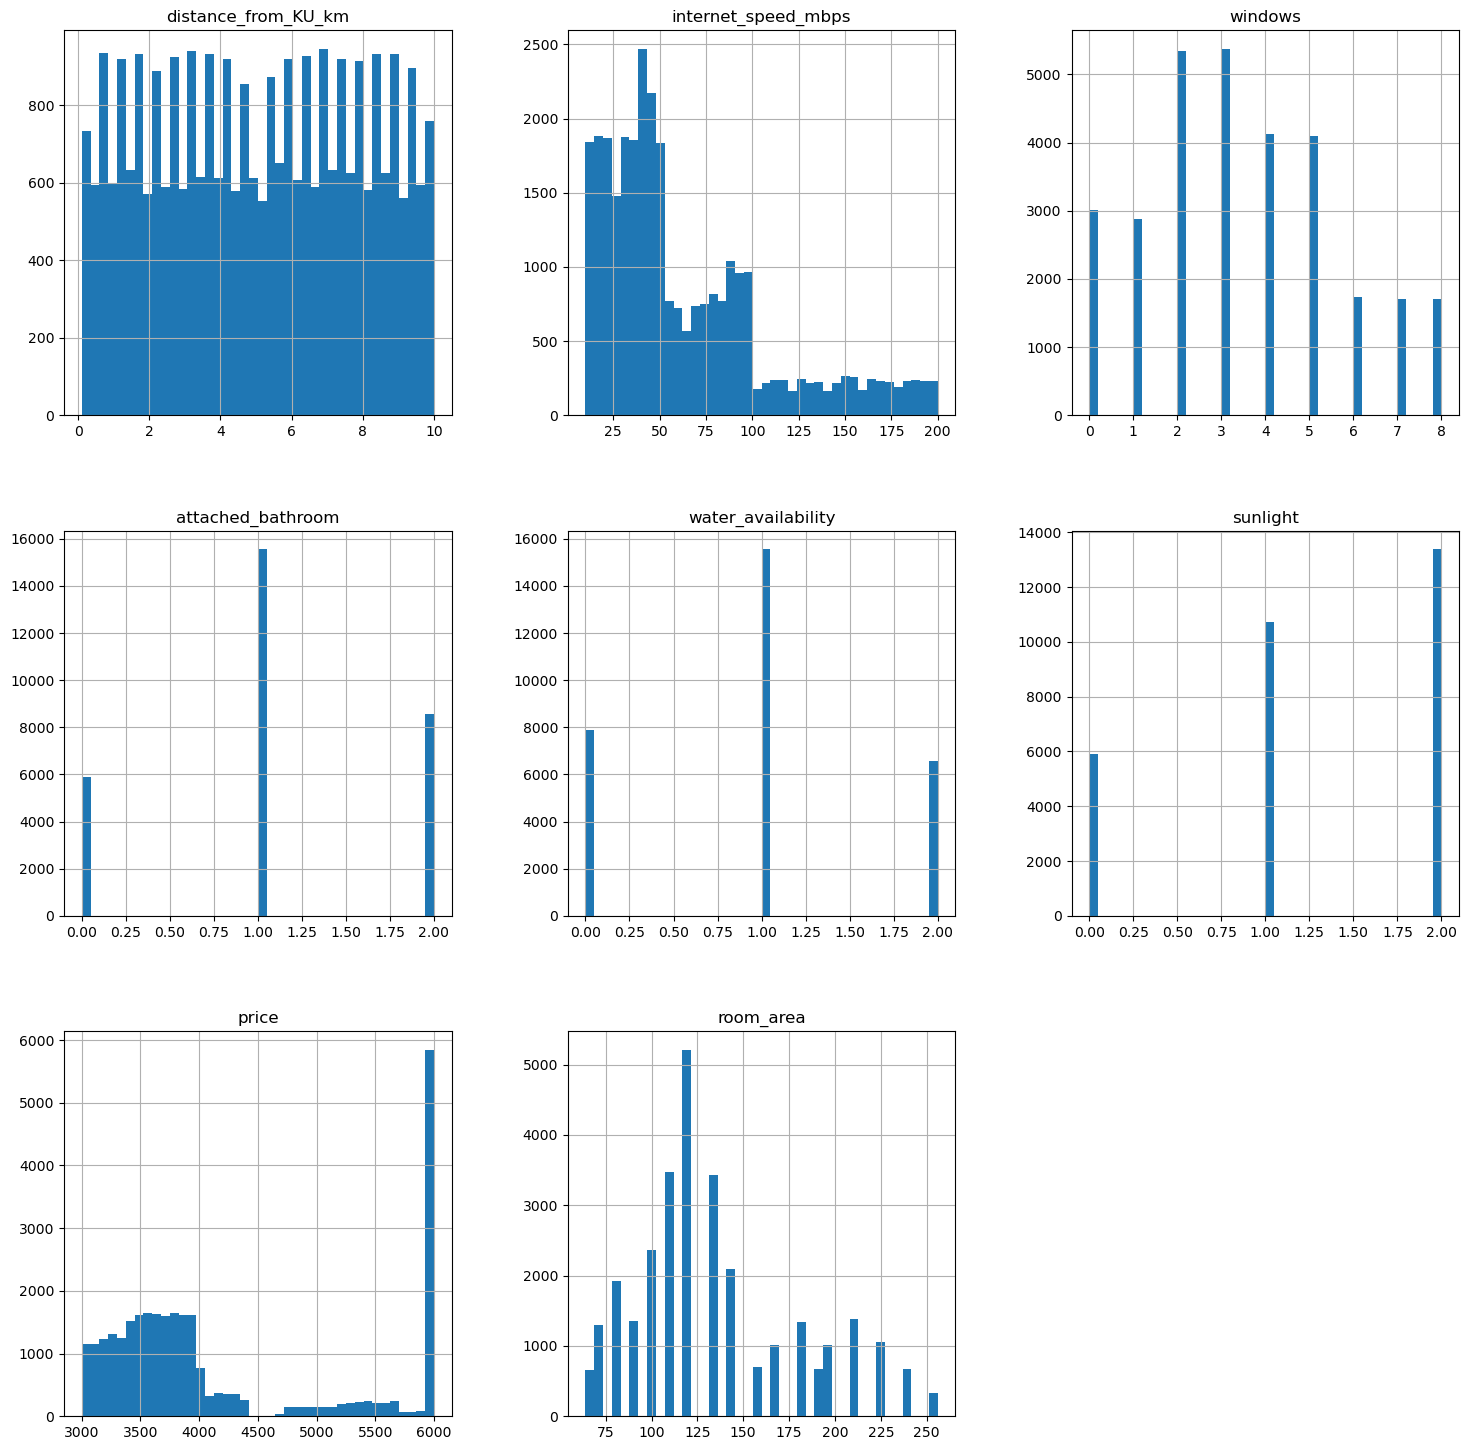

In [75]:
rooms.hist(bins=40, figsize=(18,18))
plt.show()


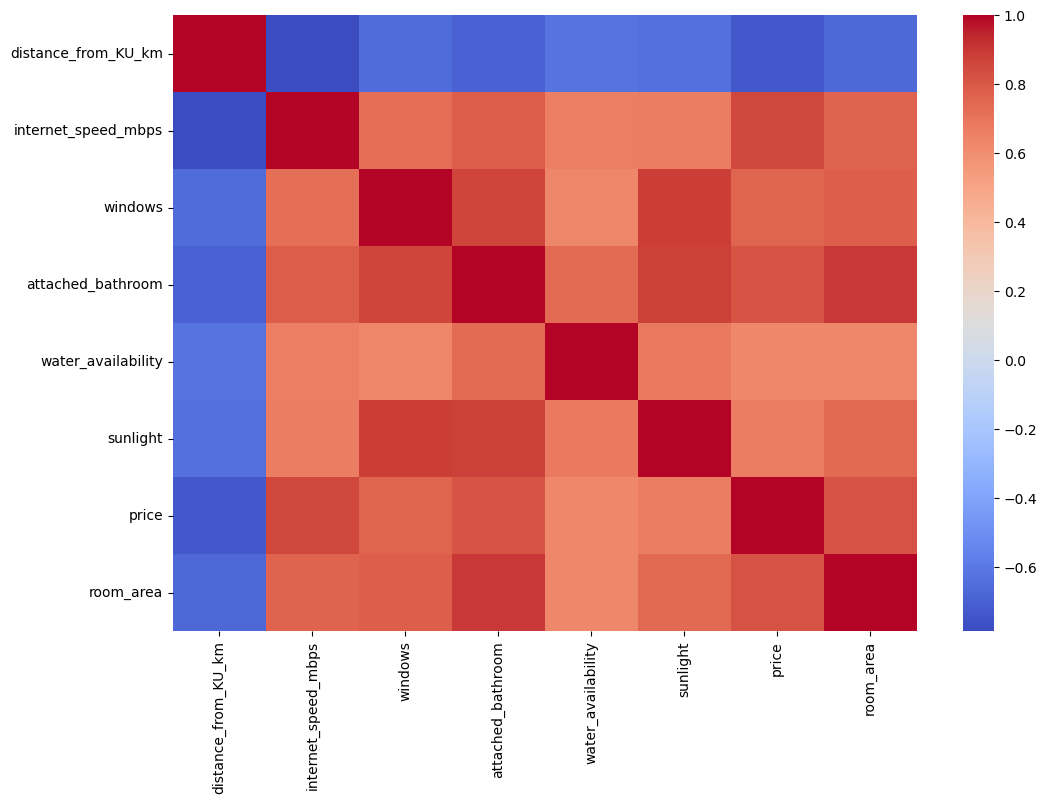

In [76]:
plt.figure(figsize=(12,8))
sns.heatmap(rooms.corr(), cmap='coolwarm')
plt.show()


In [77]:
X = rooms.drop(columns=['price'])
y = rooms['price']


In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=15
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=15
)


In [79]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor


In [80]:
models = {
    "Linear": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(random_state=15),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=15),
    "GradientBoosting": GradientBoostingRegressor(random_state=15),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=15)
}


In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds)
    })


In [82]:
results_df = pd.DataFrame(results).sort_values(by="RMSE")
results_df


,Model,MAE,RMSE,R2
3,GradientBoosting,198.972924,255.343960,0.939665
4,XGBoost,201.470139,259.848468,0.937517
2,RandomForest,214.475601,282.525711,0.926136
1,DecisionTree,270.573926,366.220365,0.875891
0,Linear,352.126782,435.941782,0.824137


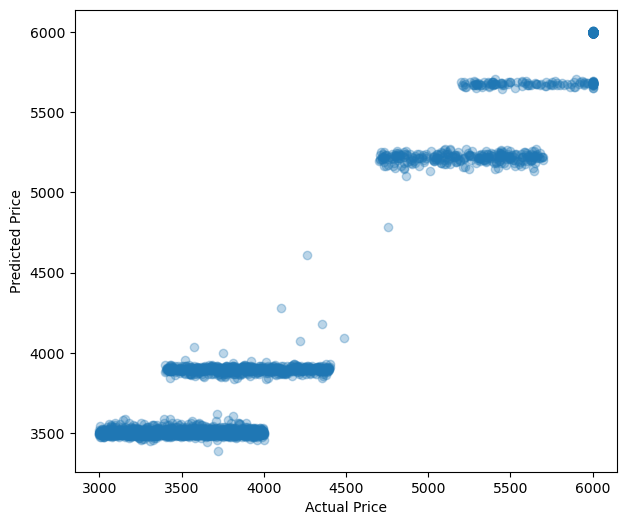

In [83]:
best_model = models[results_df.iloc[0]['Model']]
y_pred = best_model.predict(X_test)

plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()


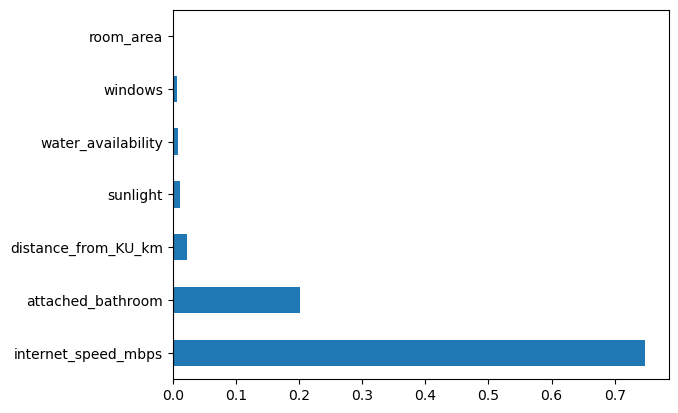

In [84]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15).plot(kind='barh')
plt.show()


In [85]:
import joblib

# Save the best model (GradientBoosting)
joblib.dump(best_model, 'room_price_model.pkl')

# Save the training column names for consistent one-hot encoding at inference time
joblib.dump(list(X.columns), 'model_columns.pkl')

print("Model saved as 'room_price_model.pkl'")
print("Training columns saved as 'model_columns.pkl'")
print(f"Columns: {list(X.columns)}")

Model saved as 'room_price_model.pkl'
Training columns saved as 'model_columns.pkl'
Columns: ['distance_from_KU_km', 'internet_speed_mbps', 'windows', 'attached_bathroom', 'water_availability', 'sunlight', 'room_area']


In [86]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = model.score(X_test, y_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append([name, r2, mae, rmse])


In [87]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "R2_Score", "MAE", "RMSE"]
)

results_df.sort_values("RMSE")


,Model,R2_Score,MAE,RMSE
3,GradientBoosting,0.939665,198.972924,255.343960
4,XGBoost,0.937517,201.470139,259.848468
2,RandomForest,0.926136,214.475601,282.525711
1,DecisionTree,0.875891,270.573926,366.220365
0,Linear,0.824137,352.126782,435.941782


In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae, rmse

(201.4701385498047, np.float64(259.84846846287166))

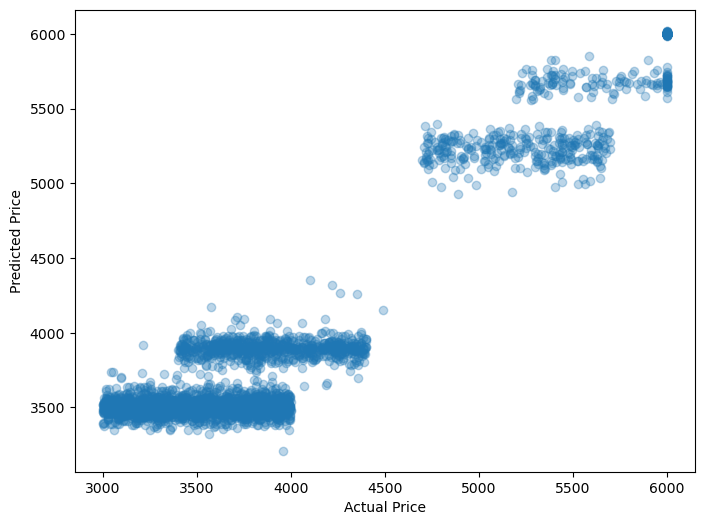

In [89]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

<Axes: >

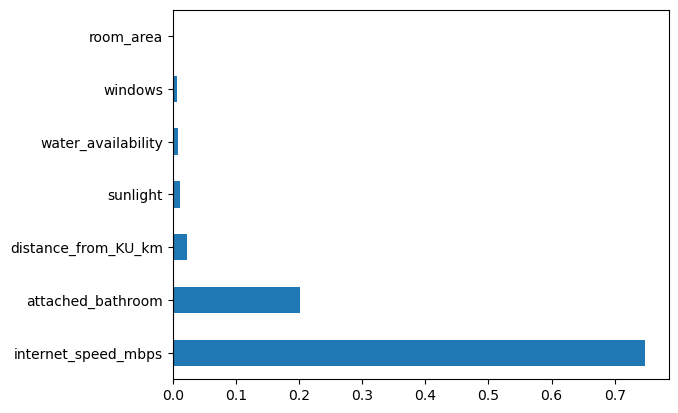

In [90]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15).plot(kind='barh')

In [91]:
new_room = pd.DataFrame({
    'distance_from_KU': [1.5],
    'internet_speed': [50],
    'num_windows': [5],
    'attached_bathroom': ['yes'],
    'room_area': [12*12],
    'water_availability': ['24/7 available'],
    'sunlight': ['good']
})

In [92]:
new_room_encoded = pd.get_dummies(new_room)
new_room_encoded = new_room_encoded.reindex(columns=X.columns, fill_value=0)

In [93]:
predicted_price = best_model.predict(new_room_encoded)
predicted_price[0]

np.float64(4403.33816957714)

In [94]:
new_room = pd.DataFrame({
    'distance_from_KU': [9.5],      
    'internet_speed': [5],          
    'number_of_windows': [1],        
    'attached_bathroom': ['shared'],
    'room_area': [6*8],              
    'water_availability': ['limited'],
    'sunlight': ['poor']
})

In [95]:
new_room_encoded = pd.get_dummies(new_room)
new_room_encoded = new_room_encoded.reindex(columns=X.columns, fill_value=0)

In [96]:
predicted_price = best_model.predict(new_room_encoded)
predicted_price[0]

np.float64(3957.068545904064)